In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Train-Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    auc
)

# Explainable AI
import shap

Load Dataset

In [ ]:
# Load dataset
df = pd.read_csv("bank.csv", sep=',')

# Display first 5 rows
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


Explore Dataset

In [ ]:
# Dataset shape
print("Shape:", df.shape)

# Column names
print(df.columns)

# Data types
print(df.info())

# Missing values
print(df.isnull().sum())

# Target distribution
print(df['deposit'].value_counts())

Shape: (11162, 17)
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null

Encode Categorical Features

In [ ]:
# Copy dataset
data = df.copy()

# Encode categorical columns
label_encoders = {}

for column in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

print(data.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   59    0        1          1        0     2343        1     0        2   
1   56    0        1          1        0       45        0     0        2   
2   41    9        1          1        0     1270        1     0        2   
3   55    7        1          1        0     2476        1     0        2   
4   54    0        1          2        0      184        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  deposit  
0    5      8      1042         1     -1         0         3        1  
1    5      8      1467         1     -1         0         3        1  
2    5      8      1389         1     -1         0         3        1  
3    5      8       579         1     -1         0         3        1  
4    5      8       673         2     -1         0         3        1  


Define Features and Target

In [ ]:
X = data.drop('deposit', axis=1)
y = data['deposit']

Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Logistic Regression Model

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

Evaluate Models
A. Confusion Matrix

In [ ]:
# Logistic Regression
cm_log = confusion_matrix(y_test, log_pred)

print("Logistic Regression Confusion Matrix")
print(cm_log)

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix")
print(cm_rf)

Logistic Regression Confusion Matrix
[[938 228]
 [258 809]]
Random Forest Confusion Matrix
[[952 214]
 [158 909]]


B.F1 Score

In [ ]:
log_f1 = f1_score(y_test, log_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Logistic Regression F1 Score:", log_f1)
print("Random Forest F1 Score:", rf_f1)

Logistic Regression F1 Score: 0.7690114068441065
Random Forest F1 Score: 0.8301369863013699


C. Classification Report

In [ ]:
print("Logistic Regression Report")
print(classification_report(y_test, log_pred))

print("Random Forest Report")
print(classification_report(y_test, rf_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      1166
           1       0.78      0.76      0.77      1067

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233

Random Forest Report
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



  ROC Curve

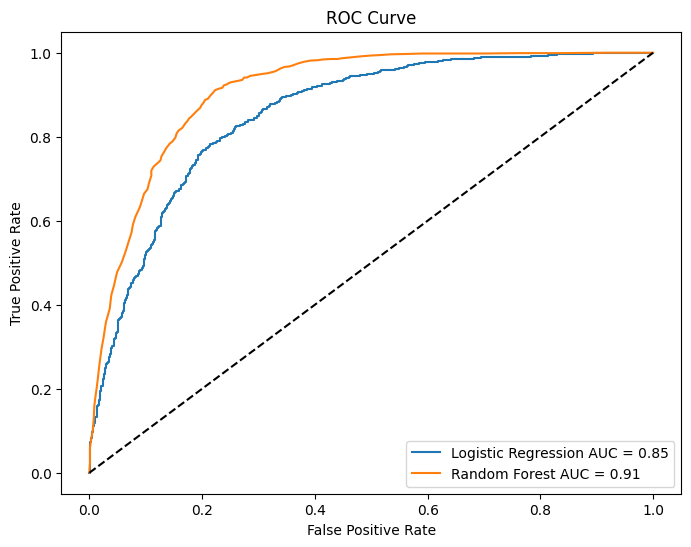

In [ ]:
# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
roc_auc_log = auc(fpr_log, tpr_log)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log,
         label=f'Logistic Regression AUC = {roc_auc_log:.2f}')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest AUC = {roc_auc_rf:.2f}')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

SHAP for Random Forest

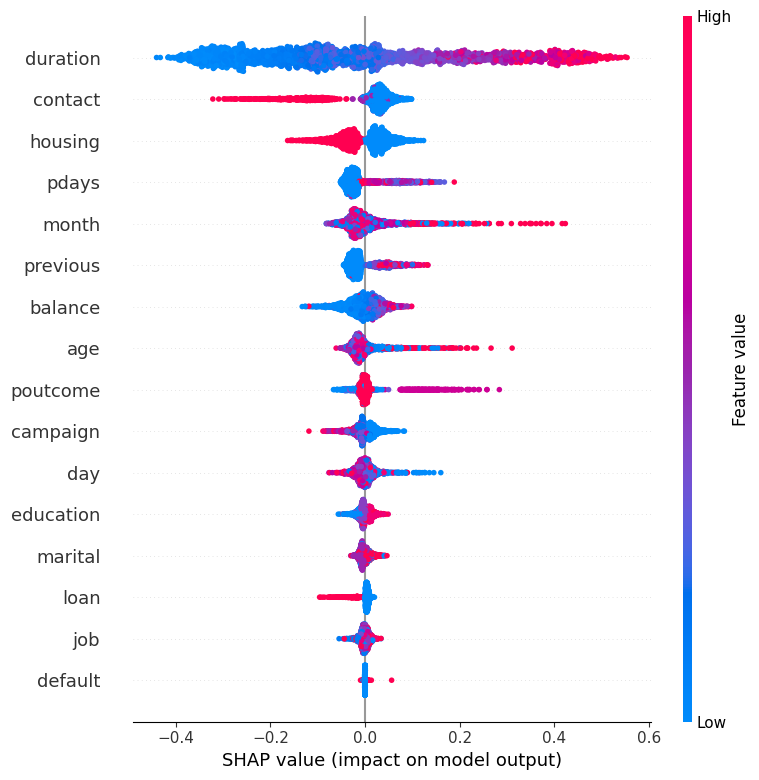

In [ ]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values[:, :, 1], X_test)

Explain 5 Individual Predictions


Prediction 1


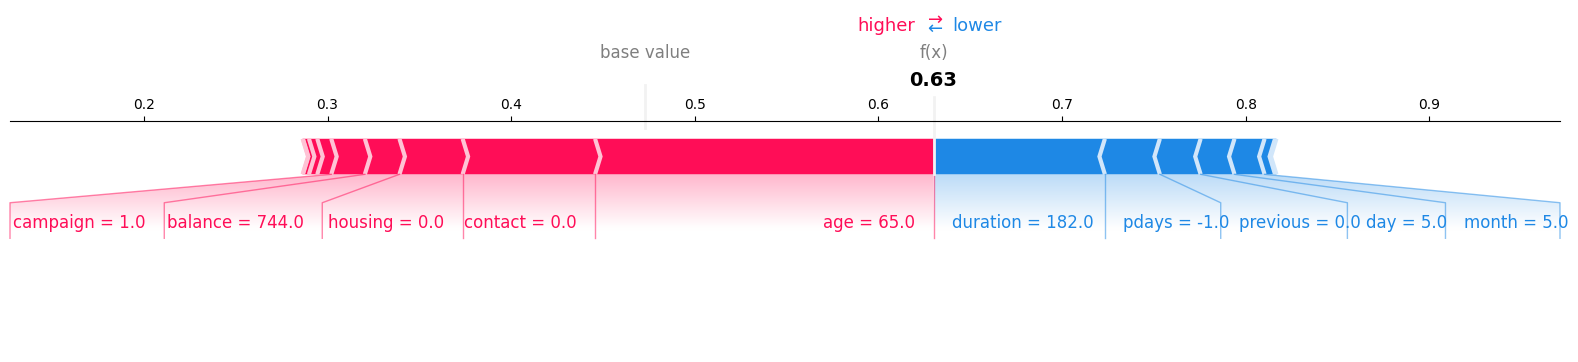


Prediction 2


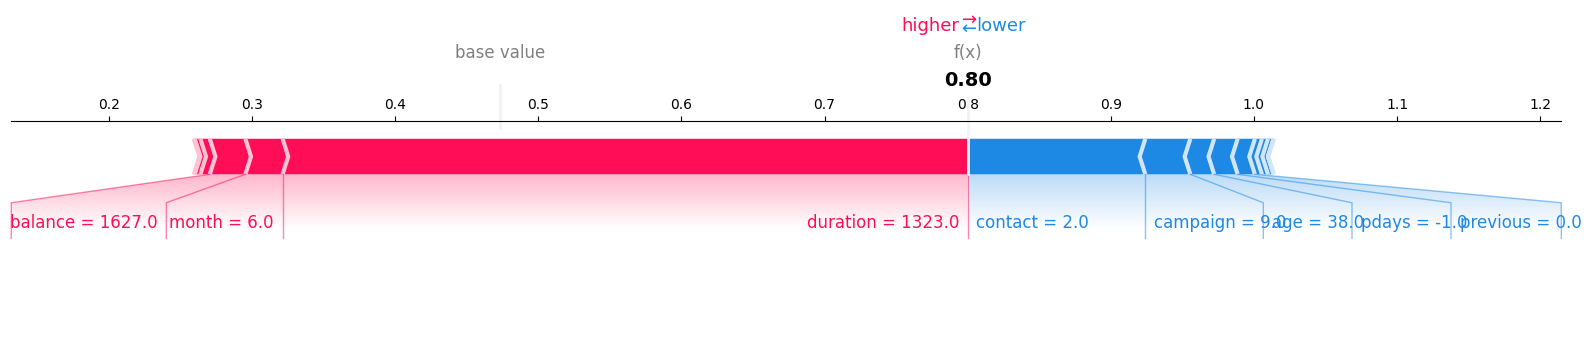


Prediction 3


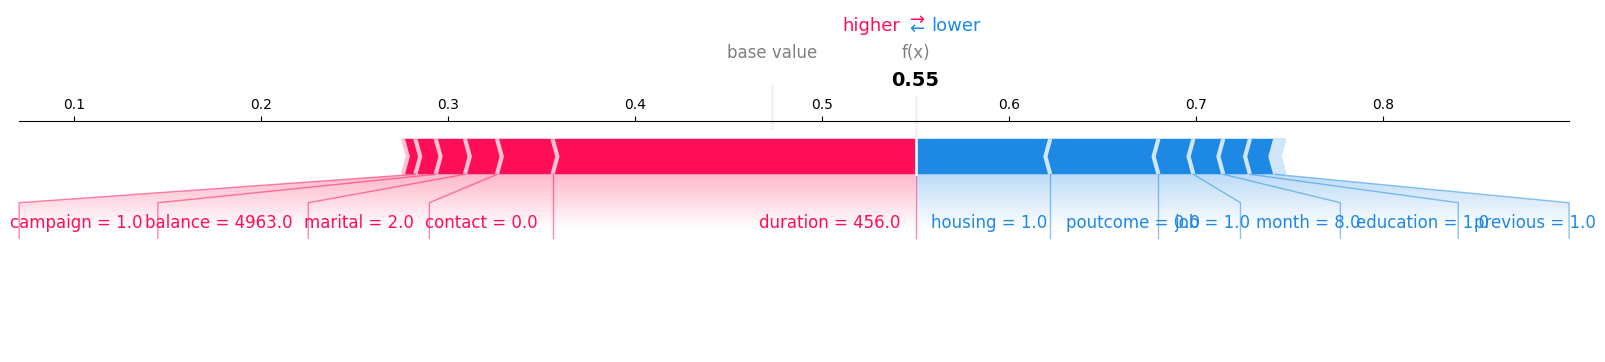


Prediction 4


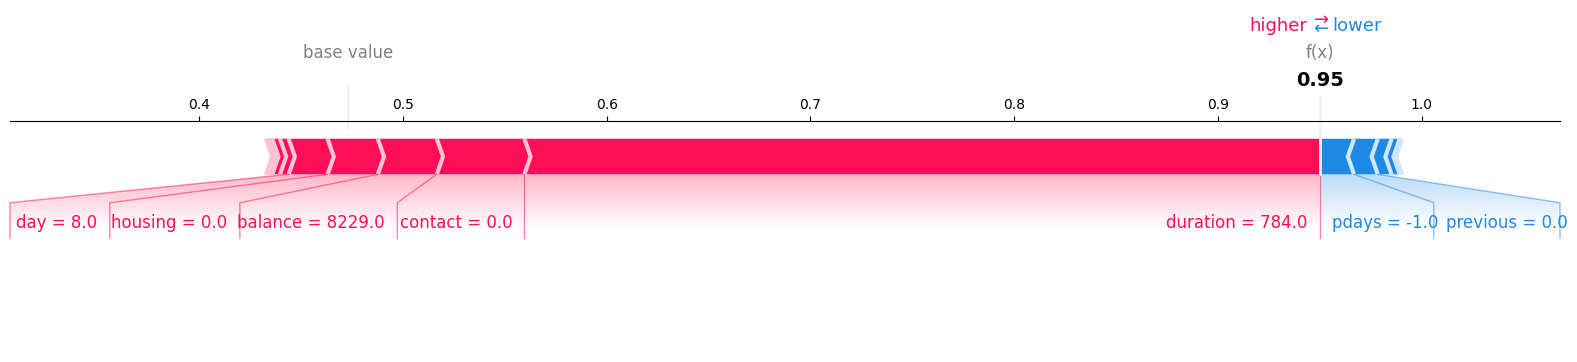


Prediction 5


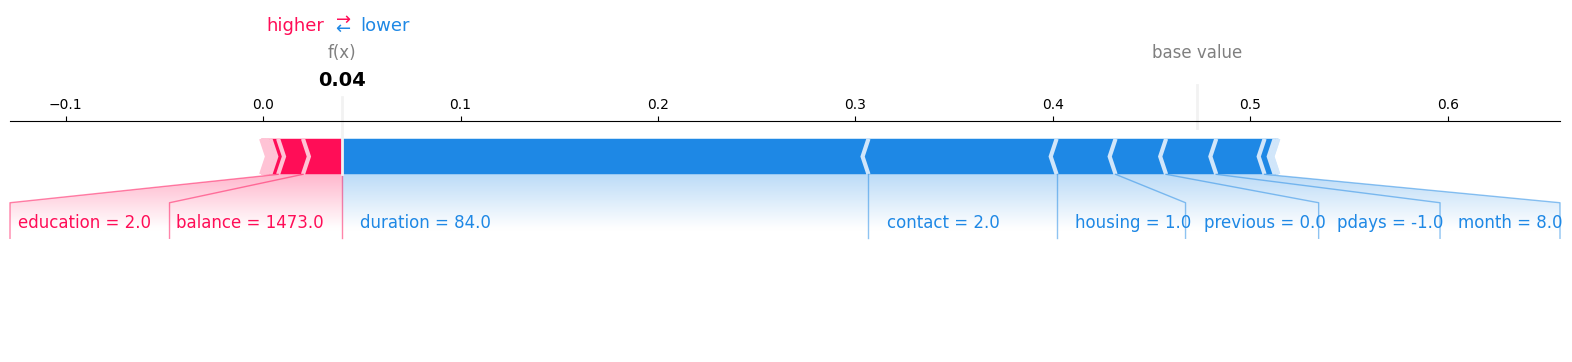

In [ ]:
for i in range(5):
    print(f"\nPrediction {i+1}")

    shap.force_plot(
        explainer.expected_value[1],
        shap_values[i, :, 1],
        X_test.iloc[i],
        matplotlib=True
    )